We will now transition into predictive and ML modeling.
We will implement a K-Means algorithm to group and profile Italian municipalities based on their accident concentrations. Subsequently, we will leverage these findings to build a Machine Learning model to extract deeper statistical insights from our data.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [4]:
input_df = pd.read_csv("data/municipality_indicators.csv")

In [ ]:
features = input_df[["Incidenti_Pro_Capite_1000","Densità_Incidenti_Kmq"]]

In [9]:
features

,Incidenti_Pro_Capite_1000,Densità_Incidenti_Kmq
0,2.652387,2.475698
1,0.000000,0.000000
2,8.694417,1.671284
3,1.386801,0.146396
4,1.450527,0.095821
...,...,...
8164,0.704473,0.021964
8165,0.492368,0.191302
8166,1.013773,0.326129
8167,0.000000,0.000000


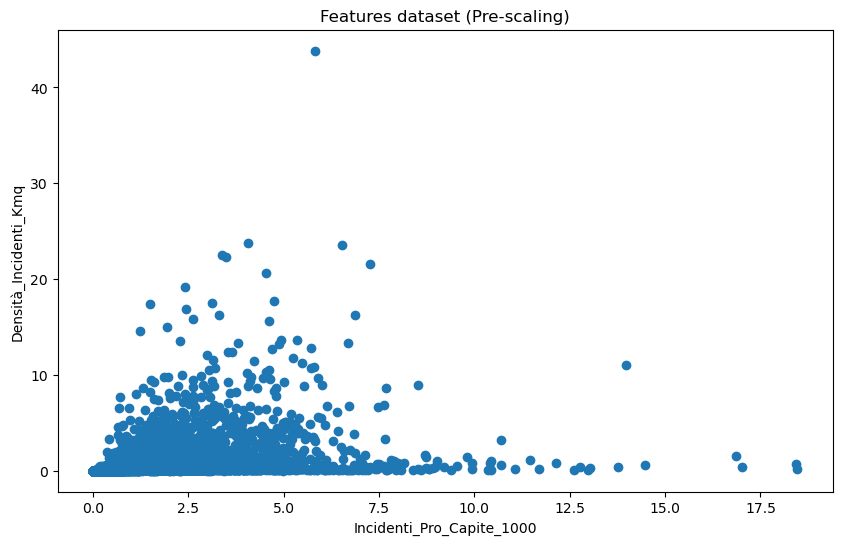

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(features["Incidenti_Pro_Capite_1000"], features["Densità_Incidenti_Kmq"], marker="o")
plt.title("Features dataset (Pre-scaling)")
plt.xlabel("Incidenti_Pro_Capite_1000")
plt.ylabel("Densità_Incidenti_Kmq")

plt.show()

In [16]:
scale_norm = MinMaxScaler()
scaled_df = pd.DataFrame(scale_norm.fit_transform(features), columns = features.columns)

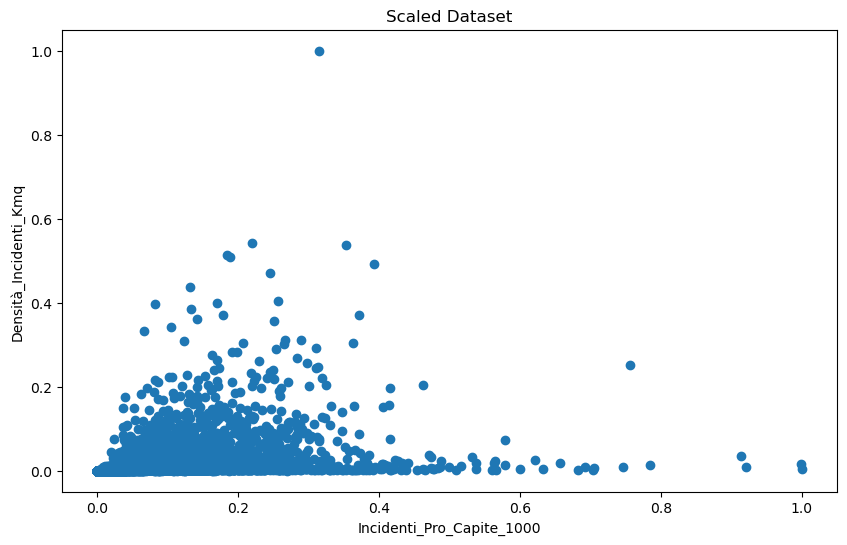

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(scaled_df["Incidenti_Pro_Capite_1000"], scaled_df["Densità_Incidenti_Kmq"], marker="o")
plt.title("Scaled Dataset")
plt.xlabel("Incidenti_Pro_Capite_1000")
plt.ylabel("Densità_Incidenti_Kmq")

plt.show()

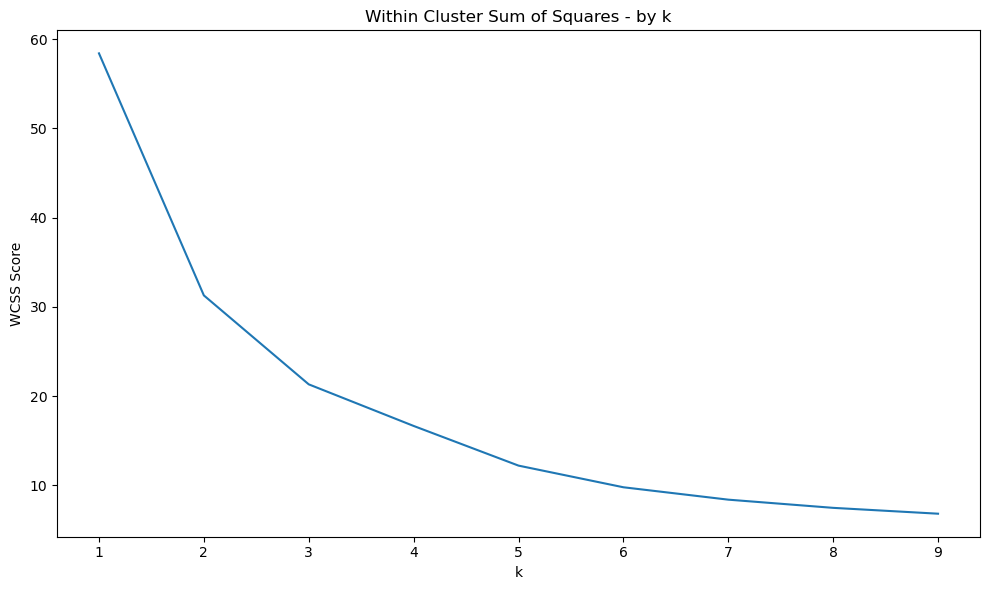

In [19]:
k_values = list(range(1,10))
wcss_list = []

for k in k_values:
	kmeans = KMeans(n_clusters = k, random_state=42)
	kmeans.fit(scaled_df)
	wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss_list)
plt.title("Within Cluster Sum of Squares - by k")
plt.xlabel("k")
plt.ylabel("WCSS Score")
plt.tight_layout()
plt.show()

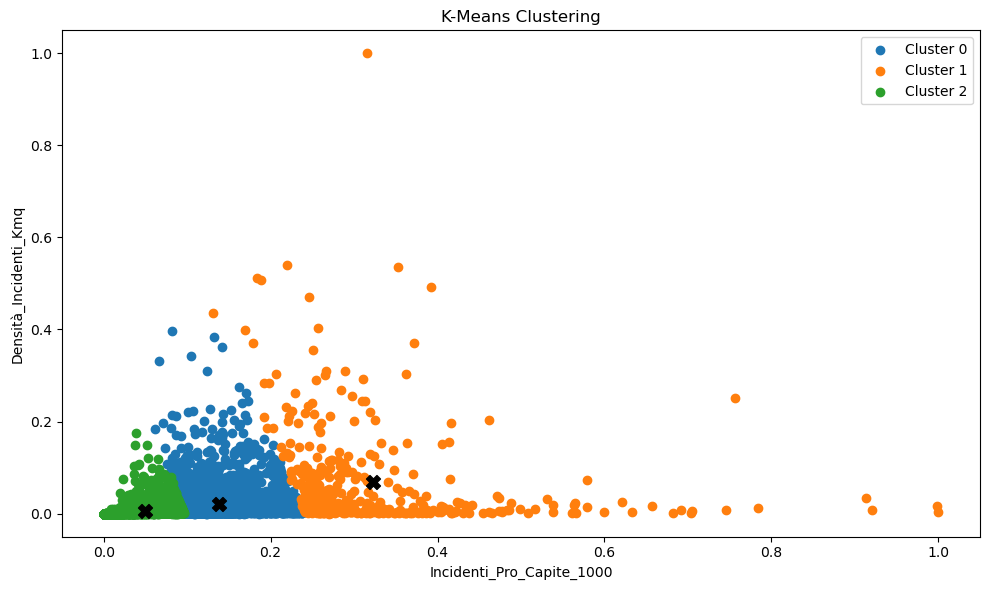

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42) #based on the elbow plot
kmeans.fit(scaled_df[["Incidenti_Pro_Capite_1000", "Densità_Incidenti_Kmq"]])

# Add the cluster labels to the DataFrame
scaled_df["cluster"] = kmeans.labels_

# Plot the clusters and centroids
centroids = kmeans.cluster_centers_
clusters = scaled_df.groupby("cluster")

plt.figure(figsize=(10, 6))
for cluster, data in clusters:
    plt.scatter(data["Incidenti_Pro_Capite_1000"], data["Densità_Incidenti_Kmq"], marker="o", label=f'Cluster {cluster}')
    plt.scatter(centroids[cluster, 0], centroids[cluster, 1], marker="X", color="black", s=100)

plt.xlabel("Incidenti_Pro_Capite_1000")
plt.ylabel("Densità_Incidenti_Kmq")
plt.title("K-Means Clustering")
plt.legend()
plt.tight_layout()
plt.show()

As observed in the plots above, the K-Means algorithm fails to produce meaningful or balanced clusters (K=3). This occurs due to the intrinsic nature of the national traffic accidents distribution. The vast majority of Italian municipalities are small-to-medium sized, characterized by very low absolute numbers of accidents and low accident densities (heavily concentrated near the origin axis).
A few massive metropolitan hubs (e.g., Rome, Milan) act as extreme outliers.
Since K-Means relies on minimizing the Euclidean distances from a centroid, these massive outliers strongly distort the position of the centroids, flattening the majority of the remaining municipalities.
To overcome this limitation without altering the distribution, we will try to shift our approach toward the DBSCAN algorithm.

In [24]:
scaled_df = scaled_df.drop(columns="cluster")

In [28]:
from sklearn.cluster import DBSCAN

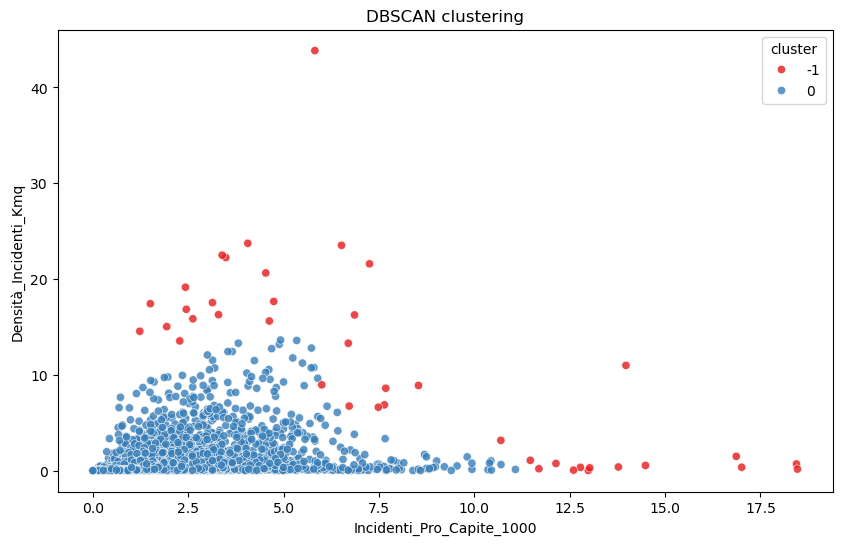

In [ ]:
dbscan = DBSCAN(eps=0.05, min_samples=10) 
#eps is "The maximum distance between two samples for one to be considered as in the neighborhood of the other". Is set at 0.05 cosidering that,
#from previous analysis, the majority of cities are small and with similar values
#min_samples is the minimum number of values required to form an independent cluster
input_df["cluster"] = dbscan.fit_predict(scaled_df) #scaled metrics to prevent features with larger scales from dominating


plt.figure(figsize=(10, 6))
#Used Seaborn for plotting convenience and simplifying color-coding of the different clusters
sns.scatterplot( 
    x=input_df["Incidenti_Pro_Capite_1000"], 
    y=input_df["Densità_Incidenti_Kmq"], 
    hue=input_df["cluster"], 
    palette="Set1",
    alpha=0.8
)
plt.title("DBSCAN clustering")
plt.show()

In [30]:
cluster_profile = input_df.groupby("cluster")[["Incidenti_Pro_Capite_1000", "Densità_Incidenti_Kmq"]].agg(["mean", "count"])
cluster_profile

Incidenti_Pro_Capite_1000       Densità_Incidenti_Kmq      
                             mean count                  mean count
cluster                                                            
-1                       8.129513    41             11.072533    41
 0                       1.704624  8128              0.555670  8128

The scatter plot displays the results applied to the normalized features.
Looking at the chart, the algorithm identified only two types of points:
Cluster 0: The vast majority of Italian municipalities. They are densely packed near the origin because they share very similar characteristics: low to moderate accident rates per capita and low accident density per square kilometer. DBSCAN recognizes this as a single group.
Cluster -1: documentation ("https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html") indicate that -1 is not a real cluster but the label for "Noisy samples". These are the points scattered along the upper and right edges of the plot (including big cities like Milan and Rome).

Ultimately, an Italian city either belong to the standard (Cluster 0) or is standalone anomaly (Cluster -1).

We will now focus on a supervised classification model to further exploit our enriched dataset. We chose the Logistic Regression model because it allows us to test the following hypothesis: can we classify whether a municipality will stand out as high-risk anomaly (Cluster -1) versus a standard baseline city (Cluster 0) using its structural characteristics(average population and square-kilometers area)?

In [34]:
#We will transform our cluster variable in binary classification. We will consider the cluster -1 as 1 (=Hihg Risk) and the cluster 0 as 0 (=Low Risk)
input_df["High Risk"] = input_df["cluster"].replace(-1,1)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
x = input_df[["Media Superficie(Kmq)", "Media Popolazione"]] #features
y = input_df["High Risk"] #variable

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [43]:
model = LogisticRegression(max_iter=1000)
results = model.fit(x_train, y_train)

In [44]:
y_pred = results.predict(x_test)

In [ ]:
#percent of correct prediction overall
accuracy = metrics.accuracy_score(y_test, y_pred)
accuracy

0.9951040391676866

The model demonstrates an exceptionally high accuracy of 99.51%. However, in the context of traffic accident risk assessment, it strongly suggests a severe class imbalance in the dataset, as we know from the DBScan clustering model.

In [47]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
confusion_matrix

array([[2436,    1],
       [  11,    3]])

- True Negatives (Low Risk correctly identified): 2,436
- False Positives (Low Risk flagged as High Risk): 1
- False Negatives (High Risk missed): 11
- True Positives (High Risk correctly identified): 3

The confusion matrix confirms the severe class imbalance.

In [ ]:
#correct positive predictions relative to total positive predictions (TP/TP+FP)
metrics.precision_score(y_test, y_pred)

0.75

A Precision score of 75% indicates that when the model predicts a city to be "High Risk," it is correct 3 out of 4 times, resulting in a very low false-alarm rate (only 1 False Positive). 

In [ ]:
#correct positive predictions relative to total actual positives (TP/TP+FN)
metrics.recall_score(y_test, y_pred)

0.21428571428571427

The Recall score of 21.43% represents the primary indicator of failure in this model. It implies that the algorithm fails to identify nearly 79% of the actual "High Risk" cities (11 out of 14 missed). 
Using this model could leave a highly dangerous area unclassified. This low recall confirms that the standard Logistic Regression algorithm is heavily biased toward the majority class.

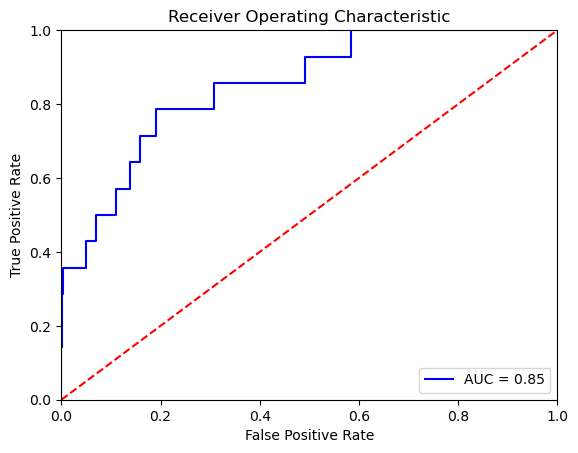

In [ ]:
#ROC tests various threshold for discriminating "High Risk" and "Low Risk". Auc indicates the overall capacity of correct discrimination.
probs = results.predict_proba(x_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# plot the ROC curve and print the AUC
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

The ROC curve yields a solid AUC score of 0.85, demonstrating that the Logistic Regression model possesses the capability to differentiate between "High Risk" and "Low Risk" cities based on population and surface area. 

Conclusion:
In its current state, this Logistic Regression model **cannot** be used for predictive operations. Due to the extreme class imbalance (driven by the structure of Italian municipalities, a lot of  small, low-density towns and a tiny fraction of major hubs like Milano that hold the vast majority of the population and traffic risks), the model has developed a heavy bias toward predicting the majority class ("Low Risk"). While its statistical accuracy is artificially high (99.51%), the low Recall (21.43%) means it could routinely fail to detect actual dangerous areas, making it functionally blind to public safety risks. 

In [ ]:
#as test, we will perform a prediction. Probably it will classified as 0 (Low Risk)
new_city = pd.DataFrame([[80, 250000]], columns=["Media Superficie(Kmq)","Media Popolazione"])
prediction = model.predict(new_city)
print(f"Predicted Risk: {prediction}")

Predicted Risk: [0]
